In [1]:
# Task 3: Heart Disease Risk Prediction Classifier

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# Fetch the classic processed UCI Heart Disease dataset directly from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Standard column schema definitions
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values="?")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Handle missing values by replacing null values with the median of that specific column
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

# Convert the multiclass target (0=Healthy, 1-4=Heart Disease Presence) into a clear Binary classification (0 vs 1)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Verify the changes
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


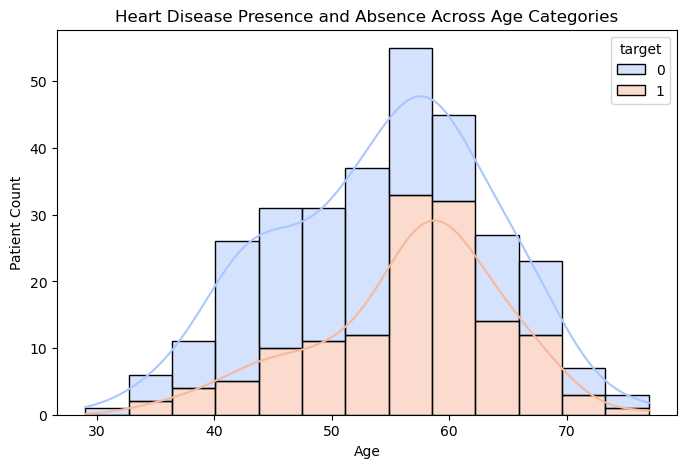

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='target', multiple='stack', palette='coolwarm', kde=True)
plt.title('Heart Disease Presence and Absence Across Age Categories')
plt.xlabel('Age')
plt.ylabel('Patient Count')
plt.show()

In [5]:
# Separate out independent features from our binary target
X = df.drop(columns=['target'])
y = df['target']

# Split data: 80% for learning patterns, 20% to validate performance metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train our binary classifier
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Generate risk target predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Model Classification Accuracy: 86.89%



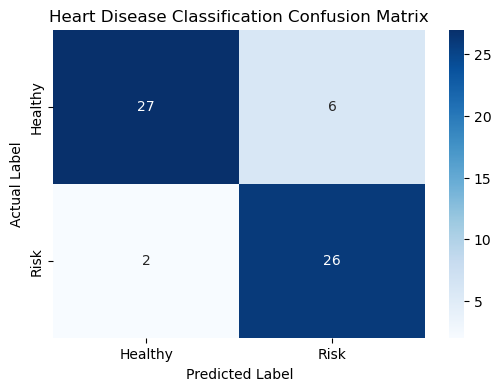

In [6]:
# Print basic accuracy metric
print(f"Model Classification Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Display the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Risk'], yticklabels=['Healthy', 'Risk'])
plt.title('Heart Disease Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

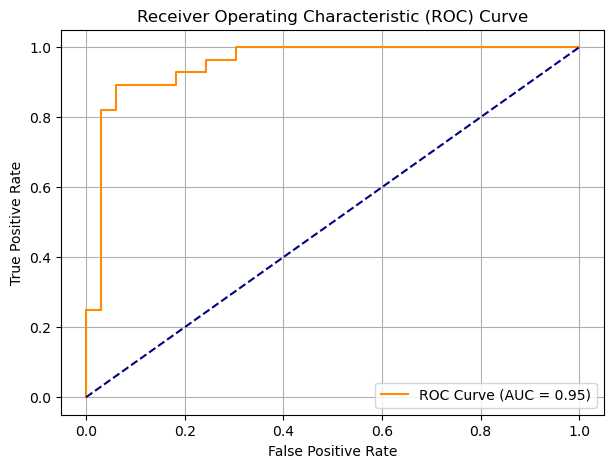

In [7]:
# Plot the Receiver Operating Characteristic (ROC) Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_5768\2786169687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


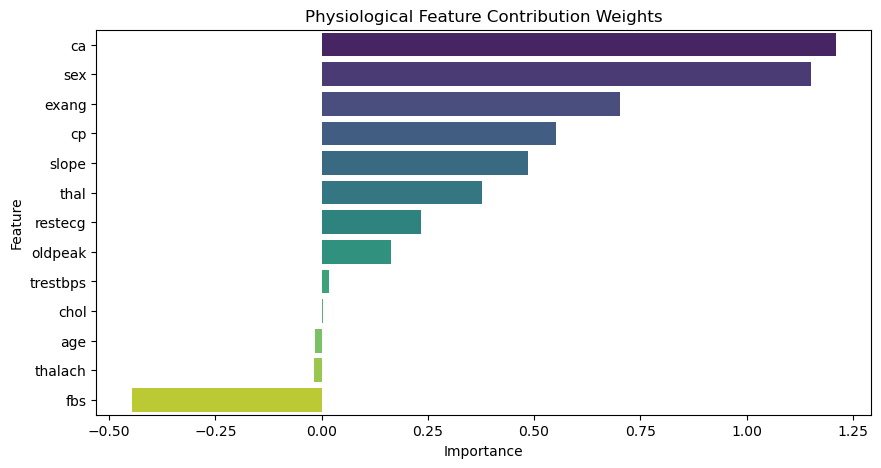

In [8]:
importance = model.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Physiological Feature Contribution Weights')
plt.show()